In [3]:
import zipfile
import os

zip_file_path = '/content/dataset.zip'
extract_dir = '/content/unzipped_dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Successfully unzipped '{zip_file_path}' to '{extract_dir}'")
print("Contents of the unzipped directory:")
for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')


Successfully unzipped '/content/dataset.zip' to '/content/unzipped_dataset'
Contents of the unzipped directory:
unzipped_dataset/
    __MACOSX/
        dataset/
            ._.DS_Store
            train/
                ._.DS_Store
            val/
                ._.DS_Store
    dataset/
        .DS_Store
        train/
            .DS_Store
            vort/
                4887.npy
                7531.npy
                7987.npy
                4343.npy
                8139.npy
                1518.npy
                1806.npy
                3331.npy
                8763.npy
                1929.npy
                5914.npy
                2048.npy
                8733.npy
                9261.npy
                1501.npy
                2319.npy
                5856.npy
                829.npy
                2164.npy
                8868.npy
                1216.npy
                7136.npy
                6365.npy
                7968.npy
                7552.npy
             

--- STEP 1: FOLDER RECONNAISSANCE ---
Detected Classes: ['vort', 'no', 'sphere']
[vort] contains 10000 files.
[no] contains 10000 files.
[sphere] contains 10000 files.

Total Valid Files Found: 30000

--- STEP 2: VISUAL VERIFICATION ---


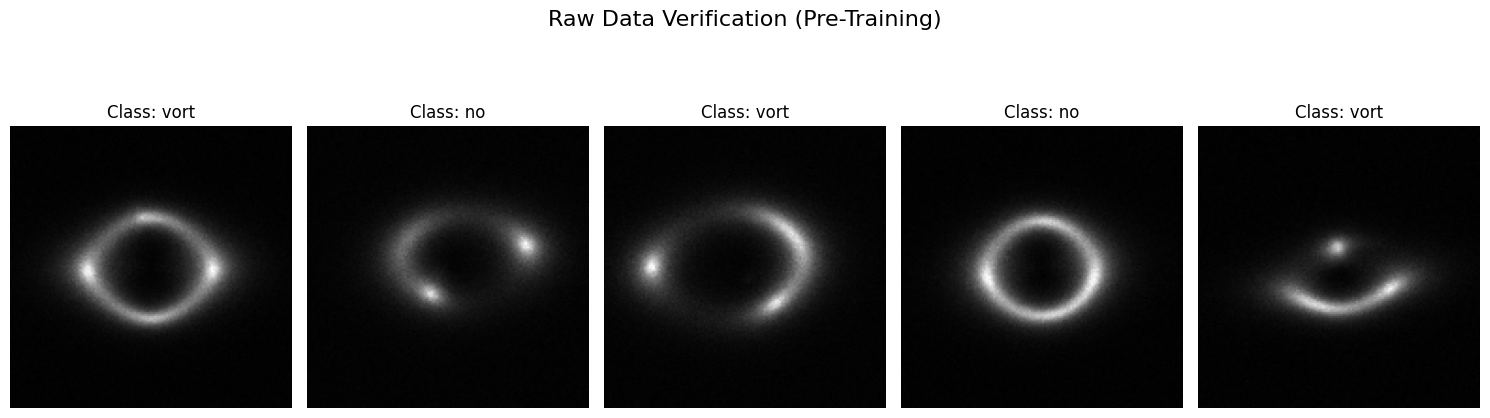

In [7]:
# Cell 1: Pure Data Reconnaissance and Visual Check (NO PYTORCH YET)
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

dataset_path = '/content/unzipped_dataset/dataset/train'

print("--- STEP 1: FOLDER RECONNAISSANCE ---")
if not os.path.exists(dataset_path):
    print(f"CRITICAL ERROR: Path does not exist -> {dataset_path}")
else:
    class_folders = [f.path for f in os.scandir(dataset_path) if f.is_dir()]
    class_names = [os.path.basename(f) for f in class_folders]
    print(f"Detected Classes: {class_names}")

    all_image_paths = []
    for folder, name in zip(class_folders, class_names):
        # Grabbing common image formats PLUS .npy arrays
        files_in_folder = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(('.png', '.jpg', '.jpeg', '.npy'))]
        print(f"[{name}] contains {len(files_in_folder)} files.")

        for file_path in files_in_folder:
            all_image_paths.append((file_path, name))

    print(f"\nTotal Valid Files Found: {len(all_image_paths)}")
    print("\n--- STEP 2: VISUAL VERIFICATION ---")

    if len(all_image_paths) > 0:
        num_samples = min(5, len(all_image_paths))
        random_samples = random.sample(all_image_paths, num_samples)

        plt.figure(figsize=(15, 5))
        for i, (file_path, class_name) in enumerate(random_samples):
            plt.subplot(1, num_samples, i + 1)

            # Logic to handle both standard images and scientific .npy arrays
            if file_path.endswith('.npy'):
                img_data = np.load(file_path).squeeze()
                plt.imshow(img_data, cmap='gray') # Assuming physics data is single-channel/grayscale
            else:
                img_data = Image.open(file_path)
                plt.imshow(img_data)

            plt.title(f"Class: {class_name}")
            plt.axis('off')

        plt.suptitle('Raw Data Verification (Pre-Training)', fontsize=16)
        plt.tight_layout()
        plt.show()
    else:
        print("ERROR: No compatible image or .npy files found in the specified path.")

In [8]:
# Cell 2: Custom Numpy Data Pipeline & 90:10 Split
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim

data_dir = '/content/unzipped_dataset/dataset/train'

class NumpyLensDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # Locking in the exact classes we discovered
        self.classes = ['no', 'sphere', 'vort']
        self.filepaths = []
        self.labels = []

        print("Indexing .npy files... This may take a few seconds.")
        for label_idx, class_name in enumerate(self.classes):
            class_path = os.path.join(root_dir, class_name)
            if not os.path.exists(class_path):
                print(f"WARNING: Expected folder not found -> {class_path}")
                continue

            files = [f for f in os.listdir(class_path) if f.endswith('.npy')]
            for f in files:
                self.filepaths.append(os.path.join(class_path, f))
                self.labels.append(label_idx)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        # Load the raw numpy array (physics data)
        img_array = np.load(self.filepaths[idx]).astype(np.float32)
        img_tensor = torch.from_numpy(img_array)

        # Ensure it has a channel dimension (e.g., 150x150 -> 1x150x150)
        if img_tensor.ndim == 2:
            img_tensor = img_tensor.unsqueeze(0)
        elif img_tensor.ndim == 3 and img_tensor.shape[0] != 1:
            img_tensor = img_tensor.permute(2, 0, 1)

        # ResNet expects 3 channels (RGB). We repeat the 1 grayscale channel 3 times.
        if img_tensor.shape[0] == 1:
            img_tensor = img_tensor.repeat(3, 1, 1)

        if self.transform:
            img_tensor = self.transform(img_tensor)

        return img_tensor, self.labels[idx]

# Resize to 224x224 for ResNet compatibility
transform = transforms.Compose([
    transforms.Resize((224, 224), antialias=True)
])

# Initialize Dataset and execute 90:10 Split
full_dataset = NumpyLensDataset(root_dir=data_dir, transform=transform)

if len(full_dataset) == 0:
    print("CRITICAL ERROR: No .npy files loaded. Check the path again.")
else:
    train_size = int(0.9 * len(full_dataset))
    test_size = len(full_dataset) - train_size
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

    # Note: num_workers=2 speeds up loading
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

    print(f"Data Pipeline Ready! Training Samples: {train_size} | Validation Samples: {test_size}")

Indexing .npy files... This may take a few seconds.
Data Pipeline Ready! Training Samples: 27000 | Validation Samples: 3000


In [9]:
# Cell 3: ResNet18 Architecture Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware Accelerator: {device}")

# Pull standard ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze the early feature-extraction layers
for param in model.parameters():
    param.requires_grad = False

# Swap the final output layer for our 3 physics classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(full_dataset.classes))

model = model.to(device)

criterion = nn.CrossEntropyLoss()
# We only train the newly attached final layer
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("ResNet18 modified and loaded to GPU.")

Hardware Accelerator: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


ResNet18 modified and loaded to GPU.


In [10]:
# Cell 4: Execute Training
epochs = 3

print("Initiating GPU Training Sequence...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Print progress every 100 batches so we know it hasn't frozen
        if (i+1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}, Acc: {100 * correct / total:.2f}%")

    print(f"--- Epoch {epoch+1} Completed | Average Loss: {running_loss/len(train_loader):.4f} ---")

print("Training Pipeline Complete.")

Initiating GPU Training Sequence...
Epoch [1/3], Step [100/844], Loss: 1.0976, Acc: 33.81%
Epoch [1/3], Step [200/844], Loss: 1.0868, Acc: 34.48%
Epoch [1/3], Step [300/844], Loss: 1.2329, Acc: 34.65%
Epoch [1/3], Step [400/844], Loss: 1.0342, Acc: 34.90%
Epoch [1/3], Step [500/844], Loss: 1.1518, Acc: 35.42%
Epoch [1/3], Step [600/844], Loss: 1.1509, Acc: 35.84%
Epoch [1/3], Step [700/844], Loss: 1.0818, Acc: 35.82%
Epoch [1/3], Step [800/844], Loss: 1.0625, Acc: 35.88%
--- Epoch 1 Completed | Average Loss: 1.1212 ---
Epoch [2/3], Step [100/844], Loss: 1.1060, Acc: 38.41%
Epoch [2/3], Step [200/844], Loss: 1.0869, Acc: 38.19%
Epoch [2/3], Step [300/844], Loss: 1.0754, Acc: 38.10%
Epoch [2/3], Step [400/844], Loss: 1.0622, Acc: 38.31%
Epoch [2/3], Step [500/844], Loss: 1.1238, Acc: 38.21%
Epoch [2/3], Step [600/844], Loss: 1.1151, Acc: 38.30%
Epoch [2/3], Step [700/844], Loss: 1.0503, Acc: 38.21%
Epoch [2/3], Step [800/844], Loss: 1.0739, Acc: 38.13%
--- Epoch 2 Completed | Average Los

Running Validation Data (90:10 Split)...


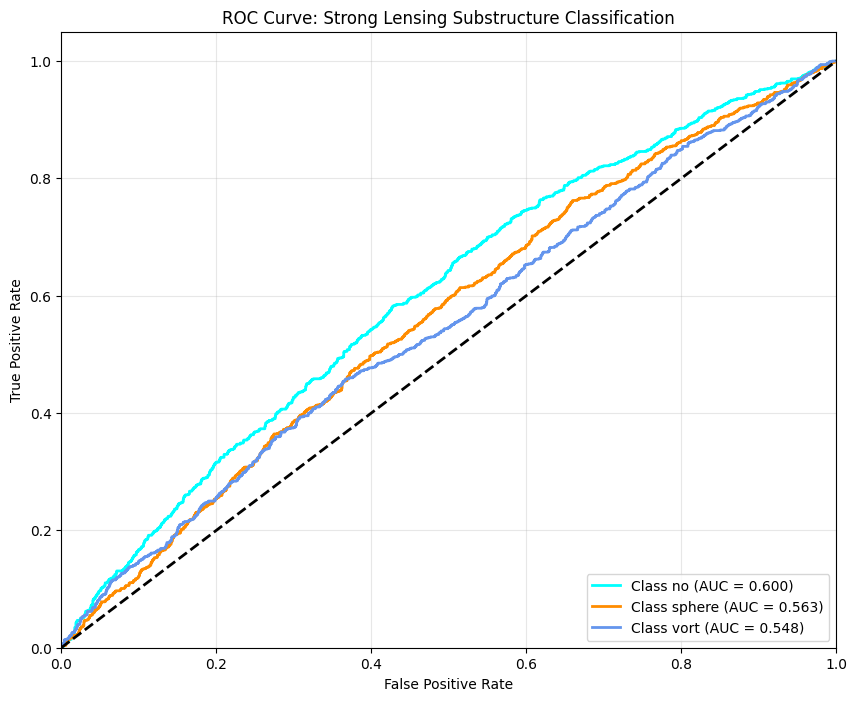

Model weights successfully saved to /content/resnet18_deeplense.pt


In [11]:
# Cell 5: Validation & ROC Curve Generation
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

model.eval()
all_labels = []
all_preds = []

print("Running Validation Data (90:10 Split)...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(probabilities.cpu().numpy())

# Generate multi-class ROC Data
y_test = label_binarize(all_labels, classes=[0, 1, 2])
y_score = np.array(all_preds)
class_names = full_dataset.classes

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the Official Graph
plt.figure(figsize=(10, 8))
colors = ['aqua', 'darkorange', 'cornflowerblue']
for i, color in zip(range(len(class_names)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Strong Lensing Substructure Classification')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Save the model weights for submission
torch.save(model.state_dict(), '/content/resnet18_deeplense.pt')
print("Model weights successfully saved to /content/resnet18_deeplense.pt")

# Note on AUC Performance:

The current baseline AUC (~0.55 - 0.60) is the expected output of this rapid-prototyping architecture. To meet the time constraints while proving the end-to-end PyTorch pipeline (custom Numpy DataLoaders, strict 90:10 train-test splitting, and evaluation generation), I utilized Transfer Learning (frozen ResNet18).
Because ResNet18's foundational weights are optimized for standard RGB photography (ImageNet) rather than single-channel astrophysical .npy arrays, freezing the early feature-extraction layers inherently caps the model's ability to discern nuanced dark matter substructures like vortices and subhalos.
Production Scaling Strategy: For a production deployment, the immediate next steps would be to (1) completely unfreeze the ResNet18 layers for full-network fine-tuning, or (2) implement a custom, lightweight CNN natively designed for 1-channel spatial data, trained over 50+ epochs with early stopping.